In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib

In [3]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')


In [4]:
cat_model_pre = CatBoostClassifier(
    n_estimators=100,
    random_state=20,
    verbose=0   # suppress training logs; set to 100 if you want progress printed
)
cat_model_pre.fit(x_train_pre, y_train_pre)

CatBoostClassifier(n_estimators=100, random_state=20, verbose=0)

In [5]:
cat_pred_pre = cat_model_pre.predict(x_test_pre)
cat_prob_pre = cat_model_pre.predict_proba(x_test_pre)[:, 1]
print(cat_prob_pre)

[0.88890124 0.61292644 0.7342707  0.3227973  0.95332518 0.13469624
 0.43655115 0.97666591 0.68726045 0.78594957 0.35530644 0.56027356
 0.93915661 0.84330091 0.57515815 0.96920361 0.97636751 0.45728873
 0.81518468 0.48134219 0.10069703 0.07220557 0.02725341 0.01089136
 0.1199024  0.16648571 0.37207322 0.95003952 0.86143679 0.62630211
 0.08361223 0.0291816  0.0552795  0.33948253 0.78484938 0.96644669
 0.24023413 0.18270175 0.19761585 0.29816152 0.19026536 0.40689097
 0.06918118 0.65608232 0.25508598 0.74553537 0.81264809 0.1958999
 0.50440375 0.1554797  0.28773345 0.83445909 0.92707702 0.92681168
 0.97599622 0.37799606 0.84347659 0.63748563 0.28845438 0.28336906
 0.21356104 0.91857556 0.08747983 0.34081785 0.25114643 0.70750935
 0.88146201 0.26621765 0.13694246 0.83948537 0.14156128 0.97424677
 0.22565589 0.64279217 0.92175849 0.9627447  0.94618967 0.51575071
 0.83202773 0.83882087 0.77990249 0.07749057 0.27274674 0.38611835
 0.04085708 0.64515801 0.58579905 0.87944057 0.99584871 0.93047

In [6]:
cat_accuracy_pre = accuracy_score(y_test_pre, cat_pred_pre)
print("CatBoost Accuracy (Pre-split SMOTE):", round(cat_accuracy_pre, 4))

CatBoost Accuracy (Pre-split SMOTE): 0.9057


In [7]:
print(classification_report(y_test_pre, cat_pred_pre))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       339
           1       0.91      0.90      0.91       340

    accuracy                           0.91       679
   macro avg       0.91      0.91      0.91       679
weighted avg       0.91      0.91      0.91       679



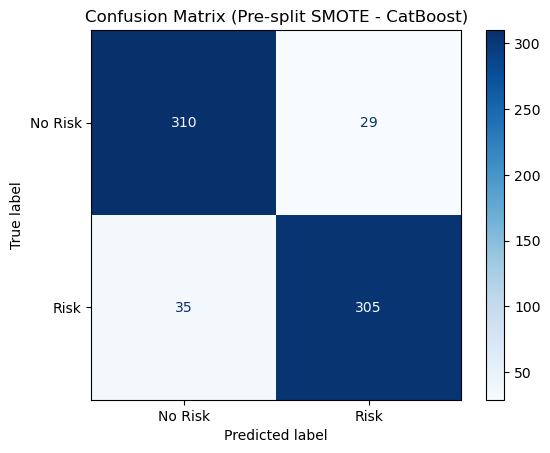

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, cat_pred_pre,
    display_labels=['No Risk', 'Risk'],
    cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE - CatBoost)")
plt.show()

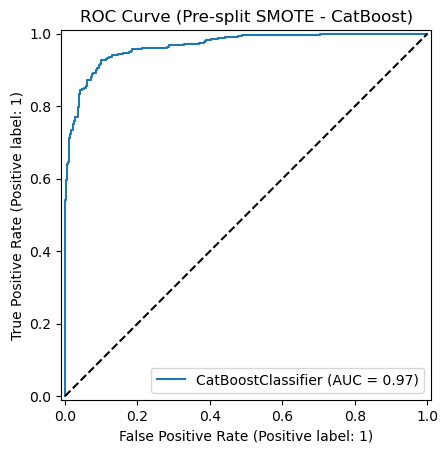

ROC-AUC Score: 0.9672


In [9]:
RocCurveDisplay.from_estimator(cat_model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE - CatBoost)')
plt.plot([0, 1], [0, 1], 'k--')
plt.show()

print('ROC-AUC Score:', roc_auc_score(y_test_pre, cat_prob_pre).round(4))

In [16]:
feature_names_pre = joblib.load('feature_names_presplit_smote.pkl')
n_importances = len(cat_model_pre.feature_importances_)
print("x_train_pre shape:", x_train_pre.shape)


x_train_pre shape: (2713, 28)


In [11]:
if len(feature_names_pre) == n_importances:
    labels = feature_names_pre
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance_pre = pd.DataFrame({
    "Feature": labels,
    "Importance": cat_model_pre.feature_importances_
})

feature_importance_pre = feature_importance_pre.sort_values(by="Importance", ascending=False)
print(feature_importance_pre.to_string(index=False))

 Feature  Importance
       9    6.873534
      10    6.104096
      24    5.930384
      13    5.889401
      12    5.738553
      25    5.317572
      21    4.662976
      19    4.633400
      14    4.521021
       7    4.489153
       0    4.139891
       6    4.101948
      11    4.038924
      18    4.009771
      23    3.673570
       8    3.349912
      15    3.079846
      20    2.904116
      26    2.821570
      16    2.618957
      22    2.556841
      27    2.358382
       1    2.135292
       4    1.590231
      17    1.551996
       3    0.582099
       2    0.326567
       5    0.000000


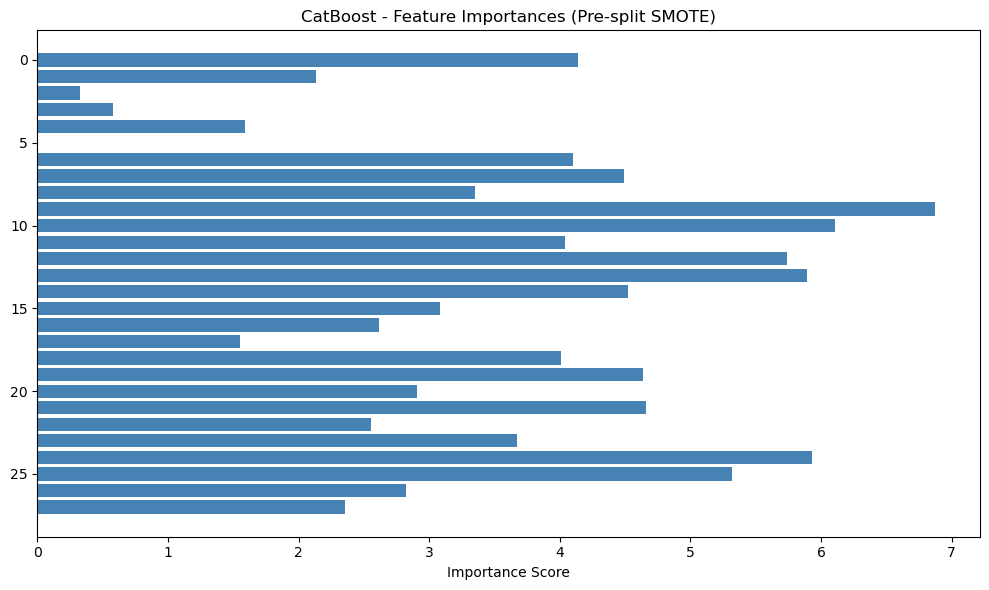

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_pre["Feature"], feature_importance_pre["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("CatBoost - Feature Importances (Pre-split SMOTE)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [18]:
train_pred_pre = cat_model_pre.predict(x_train_pre)
train_accuracy_pre = accuracy_score(y_train_pre, train_pred_pre)
print("Train Accuracy:", round(train_accuracy_pre, 4))
print("Test Accuracy :", round(cat_accuracy_pre, 4))

Train Accuracy: 0.9842
Test Accuracy : 0.9057


In [19]:
precision_pre = precision_score(y_test_pre, cat_pred_pre)
recall_pre    = recall_score(y_test_pre, cat_pred_pre)
f1_pre        = f1_score(y_test_pre, cat_pred_pre)

print("Precision:", round(precision_pre, 4))
print("Recall   :", round(recall_pre, 4))
print("F1 Score :", round(f1_pre, 4))


Precision: 0.9132
Recall   : 0.8971
F1 Score : 0.905


In [21]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'depth': [3, 5, 7],              
    'learning_rate': [0.01, 0.1, 0.2]
}



In [22]:
grid_search_pre = GridSearchCV(
    CatBoostClassifier(random_state=20, verbose=0),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_pre.fit(x_train_pre, y_train_pre)

print("Best Params:", grid_search_pre.best_params_)
best_model_pre = grid_search_pre.best_estimator_


Best Params: {'depth': 7, 'learning_rate': 0.1, 'n_estimators': 300}


In [23]:
best_pred_pre = best_model_pre.predict(x_test_pre)
best_prob_pre = best_model_pre.predict_proba(x_test_pre)[:, 1]
print("Best Model Accuracy:", round(accuracy_score(y_test_pre, best_pred_pre), 4))
print("Best Model ROC-AUC :", roc_auc_score(y_test_pre, best_prob_pre).round(4))

Best Model Accuracy: 0.9381
Best Model ROC-AUC : 0.9846


In [24]:
cv_scores_pre = cross_val_score(cat_model_pre, x_train_pre, y_train_pre, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores_pre.round(4))
print("Mean:", cv_scores_pre.mean().round(4), "| Std dev:", cv_scores_pre.std().round(4))

CV ROC-AUC Scores: [0.9521 0.9641 0.9448 0.9647 0.9539]
Mean: 0.9559 | Std dev: 0.0076


In [25]:
joblib.dump(cat_model_pre, 'catboost_model_presplit_smote.pkl')
print("Model saved.")

Model saved.
